# R3X Inhomogeneous Boundary Conditions — Demo

**R3X** is a rank-3, inhomogeneous boundary condition for cubic B-splines following Ooyama (2002).
Unlike the homogeneous R3 (which enforces $u = u' = u'' = 0$ at the boundary), R3X allows
user-specified non-zero values:

$$u(x_0) = u_0, \quad u'(x_0) = u_1, \quad u''(x_0) = u_2$$

The primary motivation is **grid nesting**, where an inner grid obtains boundary data from an
outer grid that changes each timestep.

This notebook demonstrates:
1. **1D R grid** — R3X transform round-trip testing all three BC components ($u$, $u'$, $u''$)
2. **1D R grid** — Solver with inhomogeneous Dirichlet BCs via R3X
3. **2D RR grid** — R3X with spatially varying boundary data along the j-dimension

In [1]:
using Springsteel
using CairoMakie
using LinearAlgebra

println("Springsteel  ", pkgversion(Springsteel))

Springsteel  0.3.0


---
## R3X API Overview

| Function | Purpose |
|:---------|:--------|
| `CubicBSpline.R3X` | BC constant — use in `BCL` / `BCR` dictionaries |
| `CubicBSpline.set_ahat_r3x!(spline, u0, u1, u2, side)` | Set boundary values on a single `Spline1D` |
| `set_boundary_values!(grid, side, var, u0, u1, u2)` | Grid-level interface (1D scalar args, 2D vector args) |

The gammaBC matrix for R3X is identical to R3 (rank 3, eliminates 3 border coefficients).
The difference is that `SAtransform!` automatically uses the background coefficient vector
`ahat` to carry the inhomogeneous data through the transform pipeline.

---
## Example 1 — 1D R3X Transform Round-Trip (All Three BC Components)

We use the analytic function $u(x) = e^{-x}\cos(2\pi x/L) + 2$ on $[0, L]$, which has
non-zero value, first derivative, and second derivative at both boundaries. This tests
all three R3X constraint components simultaneously.

We compare two cases:
- **R3X** with correct boundary data from the analytic function
- **R3** (homogeneous, $u = u' = u'' = 0$) — should fail to represent the function near the boundaries

In [2]:
# ── Example 1: Analytic function with non-trivial BCs ────────────────────────
L_domain = 10.0
nc = 20

# Analytic function and its derivatives
u_exact(x)   =  exp(-x/L_domain) * cos(2π*x/L_domain) + 2.0
u_exact_d1(x) = exp(-x/L_domain) * (-cos(2π*x/L_domain)/L_domain - 2π*sin(2π*x/L_domain)/L_domain)
u_exact_d2(x) = exp(-x/L_domain) * (cos(2π*x/L_domain)/L_domain^2 + 4π*sin(2π*x/L_domain)/L_domain^2 - 4π^2*cos(2π*x/L_domain)/L_domain^2)

# Print the boundary values we'll impose
println("Left  boundary:  u = ", round(u_exact(0.0), digits=6),
        "   u' = ", round(u_exact_d1(0.0), digits=6),
        "   u'' = ", round(u_exact_d2(0.0), digits=6))
println("Right boundary:  u = ", round(u_exact(L_domain), digits=6),
        "   u' = ", round(u_exact_d1(L_domain), digits=6),
        "   u'' = ", round(u_exact_d2(L_domain), digits=6))

Left  boundary:  u = 3.0   u' = -0.1   u'' = -0.384784
Right boundary:  u = 2.367879   u' = -0.036788   u'' = -0.141554


In [3]:
# ── R3X grid: set all three BC components at both boundaries ─────────────────
gp_r3x = SpringsteelGridParameters(
    geometry = "R",
    iMin = 0.0, iMax = L_domain,
    num_cells = nc,
    BCL = Dict("u" => CubicBSpline.R3X),
    BCR = Dict("u" => CubicBSpline.R3X),
    vars = Dict("u" => 1))

grid_r3x = createGrid(gp_r3x)

# Set R3X boundary values from the analytic function (all 3 components)
set_boundary_values!(grid_r3x, :left, "u",
    u_exact(0.0), u_exact_d1(0.0), u_exact_d2(0.0))
set_boundary_values!(grid_r3x, :right, "u",
    u_exact(L_domain), u_exact_d1(L_domain), u_exact_d2(L_domain))

# Load mish data, forward-transform, inverse-transform
spline_r3x = grid_r3x.ibasis.data[1, 1]
for i in 1:spline_r3x.params.mishDim
    spline_r3x.uMish[i] = u_exact(spline_r3x.mishPoints[i])
end
CubicBSpline.SBtransform!(spline_r3x)
CubicBSpline.SAtransform!(spline_r3x)
CubicBSpline.SItransform!(spline_r3x)

# ── R3 grid (homogeneous, for comparison) ────────────────────────────────────
gp_r3 = SpringsteelGridParameters(
    geometry = "R",
    iMin = 0.0, iMax = L_domain,
    num_cells = nc,
    BCL = Dict("u" => CubicBSpline.R3),
    BCR = Dict("u" => CubicBSpline.R3),
    vars = Dict("u" => 1))

grid_r3 = createGrid(gp_r3)
spline_r3 = grid_r3.ibasis.data[1, 1]
for i in 1:spline_r3.params.mishDim
    spline_r3.uMish[i] = u_exact(spline_r3.mishPoints[i])
end
CubicBSpline.SBtransform!(spline_r3)
CubicBSpline.SAtransform!(spline_r3)
CubicBSpline.SItransform!(spline_r3)

# Report errors
err_r3x = maximum(abs.(spline_r3x.uMish .- u_exact.(spline_r3x.mishPoints)))
err_r3  = maximum(abs.(spline_r3.uMish  .- u_exact.(spline_r3.mishPoints)))
println("R3X max error: ", err_r3x)
println("R3  max error: ", err_r3, "  (expected: large near boundaries)")

R3X max error: 0.00010619499852237979
R3  max error: 2.9926830699710103  (expected: large near boundaries)


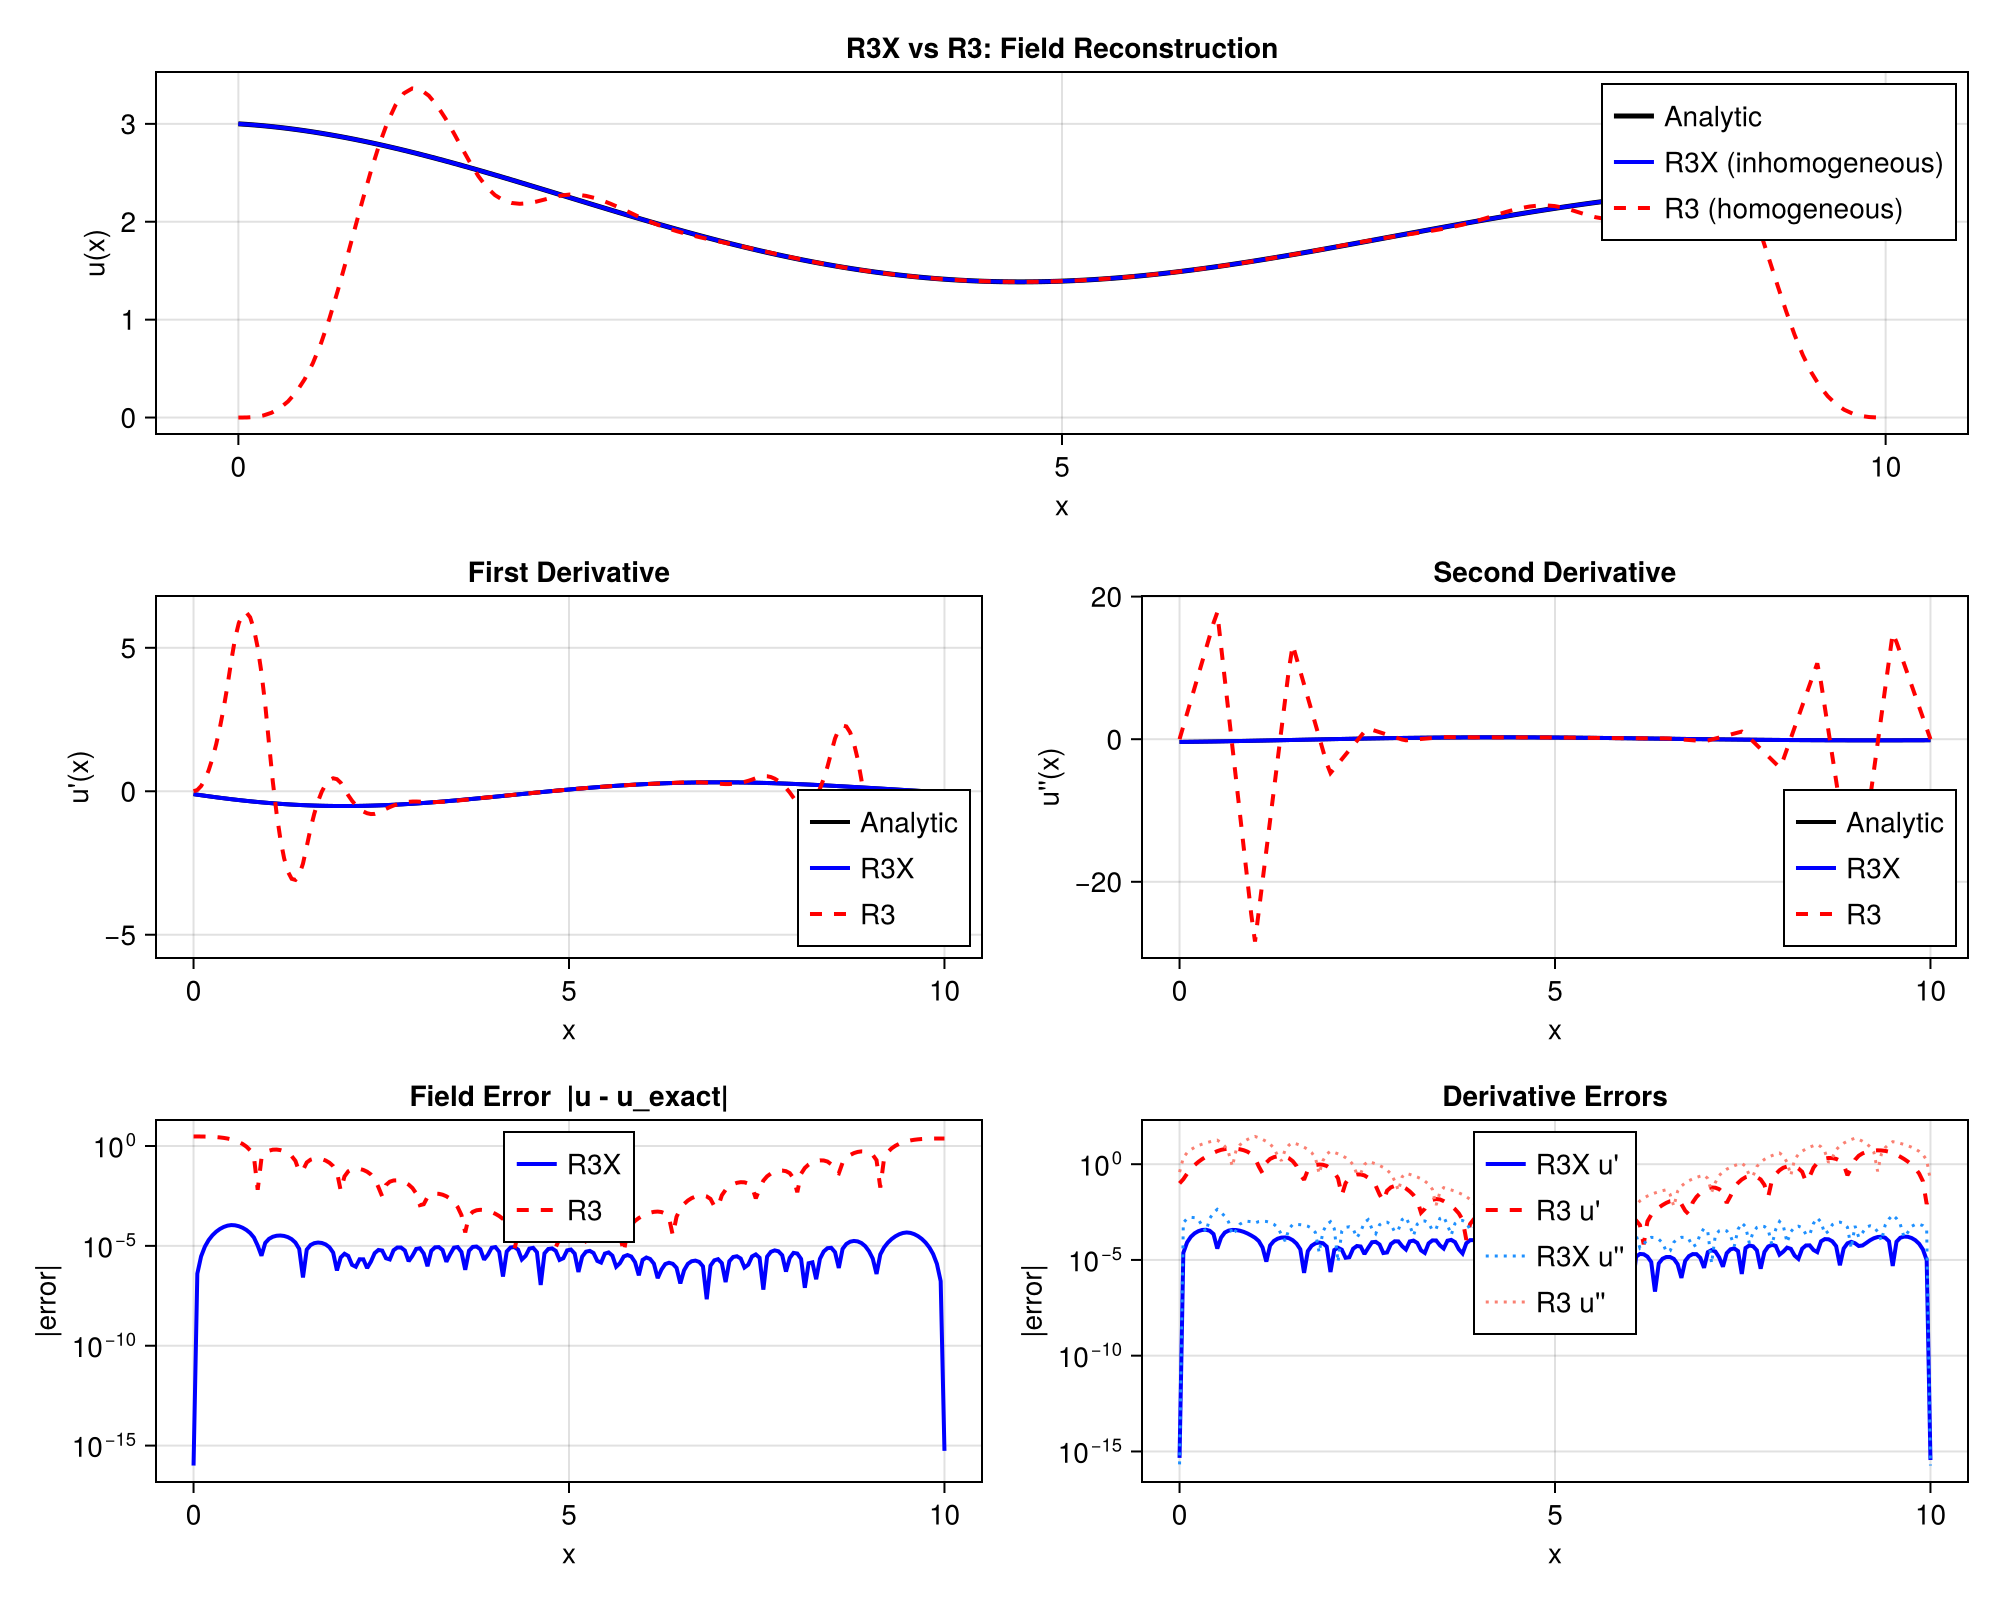

In [4]:
# ── Example 1: Visualization — field reconstruction ──────────────────────────
# Evaluate on a dense regular grid for smooth plots
x_fine = collect(range(spline_r3x.params.xmin, spline_r3x.params.xmax, length=200))
u_fine_r3x = [CubicBSpline.SItransform(spline_r3x.params, spline_r3x.a, x, 0) for x in x_fine]
u_fine_r3  = [CubicBSpline.SItransform(spline_r3.params,  spline_r3.a,  x, 0) for x in x_fine]
u_fine_exact = u_exact.(x_fine)

fig1 = Figure(size = (1000, 800))

# Top row: field comparison
ax1a = Axis(fig1[1,1:2], xlabel = "x", ylabel = "u(x)",
            title = "R3X vs R3: Field Reconstruction")
lines!(ax1a, x_fine, u_fine_exact, label = "Analytic", linewidth = 2.5, color = :black)
lines!(ax1a, x_fine, u_fine_r3x,  label = "R3X (inhomogeneous)", linewidth = 2, color = :blue)
lines!(ax1a, x_fine, u_fine_r3,   label = "R3 (homogeneous)",    linewidth = 2, color = :red,
       linestyle = :dash)
axislegend(ax1a, position = :rt)

# Middle row: all three BC components (derivatives)
u_d1_r3x = [CubicBSpline.SItransform(spline_r3x.params, spline_r3x.a, x, 1) for x in x_fine]
u_d1_r3  = [CubicBSpline.SItransform(spline_r3.params,  spline_r3.a,  x, 1) for x in x_fine]
u_d1_exact = u_exact_d1.(x_fine)

u_d2_r3x = [CubicBSpline.SItransform(spline_r3x.params, spline_r3x.a, x, 2) for x in x_fine]
u_d2_r3  = [CubicBSpline.SItransform(spline_r3.params,  spline_r3.a,  x, 2) for x in x_fine]
u_d2_exact = u_exact_d2.(x_fine)

ax1b = Axis(fig1[2,1], xlabel = "x", ylabel = "u'(x)",
            title = "First Derivative")
lines!(ax1b, x_fine, u_d1_exact, label = "Analytic", linewidth = 2, color = :black)
lines!(ax1b, x_fine, u_d1_r3x,  label = "R3X",      linewidth = 2, color = :blue)
lines!(ax1b, x_fine, u_d1_r3,   label = "R3",        linewidth = 2, color = :red, linestyle = :dash)
axislegend(ax1b, position = :rb)

ax1c = Axis(fig1[2,2], xlabel = "x", ylabel = "u''(x)",
            title = "Second Derivative")
lines!(ax1c, x_fine, u_d2_exact, label = "Analytic", linewidth = 2, color = :black)
lines!(ax1c, x_fine, u_d2_r3x,  label = "R3X",      linewidth = 2, color = :blue)
lines!(ax1c, x_fine, u_d2_r3,   label = "R3",        linewidth = 2, color = :red, linestyle = :dash)
axislegend(ax1c, position = :rb)

# Bottom row: pointwise errors
ax1d = Axis(fig1[3,1], xlabel = "x", ylabel = "|error|",
            title = "Field Error  |u - u_exact|", yscale = log10)
lines!(ax1d, x_fine, abs.(u_fine_r3x .- u_fine_exact) .+ 1e-16,
       label = "R3X", linewidth = 2, color = :blue)
lines!(ax1d, x_fine, abs.(u_fine_r3 .- u_fine_exact) .+ 1e-16,
       label = "R3",  linewidth = 2, color = :red, linestyle = :dash)
axislegend(ax1d, position = :ct)

ax1e = Axis(fig1[3,2], xlabel = "x", ylabel = "|error|",
            title = "Derivative Errors", yscale = log10)
lines!(ax1e, x_fine, abs.(u_d1_r3x .- u_d1_exact) .+ 1e-16,
       label = "R3X u'", linewidth = 2, color = :blue)
lines!(ax1e, x_fine, abs.(u_d1_r3 .- u_d1_exact) .+ 1e-16,
       label = "R3 u'",  linewidth = 2, color = :red, linestyle = :dash)
lines!(ax1e, x_fine, abs.(u_d2_r3x .- u_d2_exact) .+ 1e-16,
       label = "R3X u''", linewidth = 1.5, color = :dodgerblue, linestyle = :dot)
lines!(ax1e, x_fine, abs.(u_d2_r3 .- u_d2_exact) .+ 1e-16,
       label = "R3 u''",  linewidth = 1.5, color = :salmon, linestyle = :dot)
axislegend(ax1e, position = :ct)

fig1

---
## Example 2 — 1D Poisson Solver with R3X BCs

Solve $u''(x) = f(x)$ on $[0, 1]$ with **non-zero Dirichlet** boundary conditions
enforced via R3X:

$$u(0) = 1, \quad u(1) = 3$$

Using the manufactured solution $u(x) = 1 + 2x + \sin(\pi x)$, which gives:
- $f(x) = -\pi^2 \sin(\pi x)$
- Left BC: $u(0) = 1$, $u'(0) = 2 + \pi$, $u''(0) = 0$
- Right BC: $u(1) = 3$, $u'(1) = 2 - \pi$, $u''(1) = 0$

This demonstrates the solver's ability to handle inhomogeneous BCs — the linear part
$1 + 2x$ is carried entirely by the R3X `ahat` background, while the interior solve
recovers the $\sin(\pi x)$ correction.

In [5]:
# ── Example 2: 1D Poisson with R3X ───────────────────────────────────────────
nc2 = 30

# Manufactured solution
u2_exact(x)   = 1.0 + 2.0*x + sin(π*x)
u2_exact_d1(x) = 2.0 + π*cos(π*x)
u2_exact_d2(x) = -π^2*sin(π*x)

gp2 = SpringsteelGridParameters(
    geometry = "R",
    iMin = 0.0, iMax = 1.0,
    num_cells = nc2,
    BCL = Dict("u" => CubicBSpline.R3X),
    BCR = Dict("u" => CubicBSpline.R3X),
    vars = Dict("u" => 1))
grid2 = createGrid(gp2)

# Set all three BC components at each boundary
set_boundary_values!(grid2, :left, "u",
    u2_exact(0.0), u2_exact_d1(0.0), u2_exact_d2(0.0))
set_boundary_values!(grid2, :right, "u",
    u2_exact(1.0), u2_exact_d1(1.0), u2_exact_d2(1.0))

# Assemble and solve
L2 = assemble_from_equation(grid2, "u"; d_ii=1.0)
pts2 = solver_gridpoints(grid2, "u")
f2 = -π^2 .* sin.(π .* pts2)

prob2 = SpringsteelProblem(grid2; operator=L2, rhs=f2,
                            parameters=Dict{String,Any}("var" => "u"))
sol2 = solve(prob2)

println("Converged: ", sol2.converged)
println("Max error: ", maximum(abs.(sol2.physical .- u2_exact.(pts2))))

Converged: true
Max error: 1.7822744895035214e-5


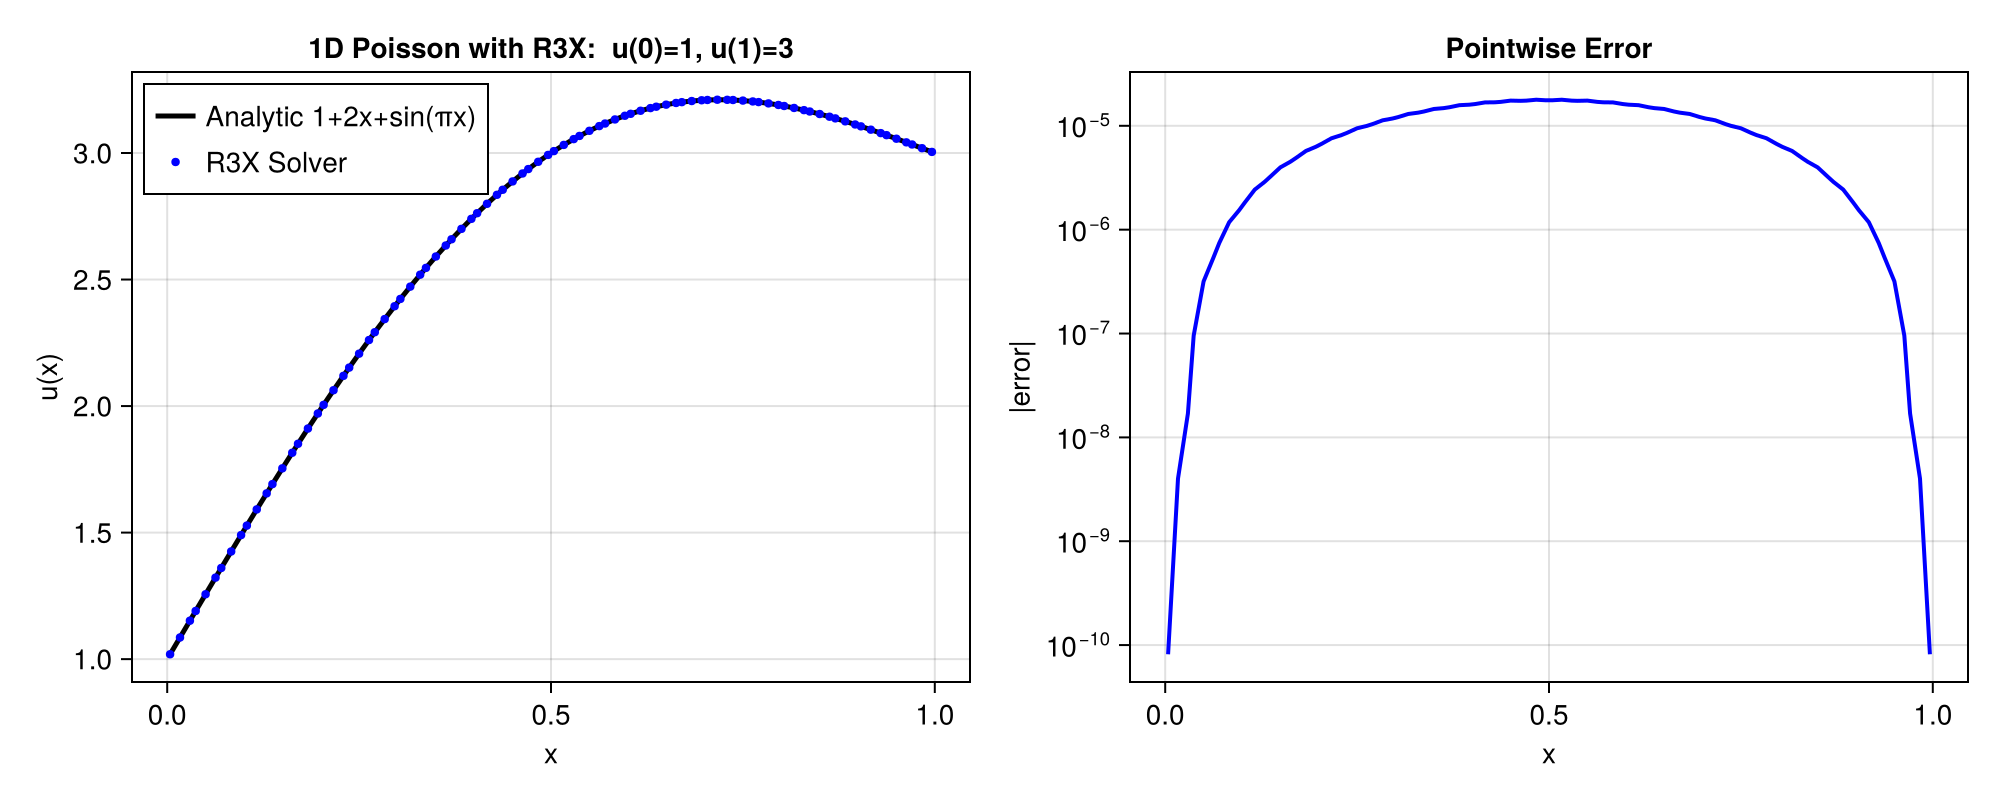

In [6]:
# ── Example 2: Visualization ─────────────────────────────────────────────────
fig2 = Figure(size = (1000, 400))

ax2a = Axis(fig2[1,1], xlabel = "x", ylabel = "u(x)",
            title = "1D Poisson with R3X:  u(0)=1, u(1)=3")
lines!(ax2a, pts2, u2_exact.(pts2), label = "Analytic 1+2x+sin(πx)", linewidth = 2.5, color = :black)
scatter!(ax2a, pts2, sol2.physical, label = "R3X Solver", markersize = 6, color = :blue)
axislegend(ax2a, position = :lt)

ax2b = Axis(fig2[1,2], xlabel = "x", ylabel = "|error|",
            title = "Pointwise Error", yscale = log10)
errs2 = abs.(sol2.physical .- u2_exact.(pts2)) .+ 1e-16
lines!(ax2b, pts2, errs2, color = :blue, linewidth = 2)

fig2

---
## Example 3 — 2D RR Grid with Spatially Varying R3X Boundary

Solve the 2D Laplacian $\nabla^2 u = \partial^2 u/\partial x^2 + \partial^2 u/\partial y^2 = 0$
on a Spline$\times$Spline (RR) grid $[0,1] \times [0,1]$ with:
- **R3X on the left i-boundary** ($x=0$): $u(0, y) = \sin(\pi y)$ (varies along $y$)
- **R3X on the right i-boundary** ($x=1$): $u(1, y) = 0$
- **R1T0 (Dirichlet zero)** on both j-boundaries

The analytic solution to Laplace's equation with these BCs is:

$$u(x,y) = \frac{\sinh(\pi(1-x))}{\sinh(\pi)} \sin(\pi y)$$

This demonstrates `set_boundary_values!` on a 2D grid, where the boundary data
(a function of $y$) is automatically transformed to j-spectral space internally.

In [7]:
# ── Example 3: 2D RR Laplace with spatially varying R3X BC ───────────────────
nc_i = 15   # i-dimension (x) spline cells
nc_j = 15   # j-dimension (y) spline cells
jDim = nc_j * 3
b_jDim = nc_j + 3

gp3 = SpringsteelGridParameters(
    geometry = "RR",
    iMin = 0.0, iMax = 1.0,
    num_cells = nc_i,
    jMin = 0.0, jMax = 1.0,
    jDim = jDim,
    b_jDim = b_jDim,
    BCL = Dict("u" => CubicBSpline.R3X),
    BCR = Dict("u" => CubicBSpline.R3X),
    BCU = Dict("u" => CubicBSpline.R1T0),   # u(x,0) = 0
    BCD = Dict("u" => CubicBSpline.R1T0),   # u(x,1) = 0
    vars = Dict("u" => 1))
grid3 = createGrid(gp3)

# Analytic solution
u3_exact(x, y) = sinh(π*(1.0 - x)) / sinh(π) * sin(π*y)
u3_exact_dx(x, y) = -π * cosh(π*(1.0 - x)) / sinh(π) * sin(π*y)
u3_exact_dxx(x, y) = π^2 * sinh(π*(1.0 - x)) / sinh(π) * sin(π*y)

# Get j-dimension mish points (physical y-coordinates along the boundary)
y_mish = grid3.jbasis.data[1, 1].mishPoints

# Left boundary (x=0): u(0,y) = sin(πy), u'(0,y), u''(0,y) along y-mish
u0_left  = [u3_exact(0.0, y)     for y in y_mish]
u1_left  = [u3_exact_dx(0.0, y)  for y in y_mish]
u2_left  = [u3_exact_dxx(0.0, y) for y in y_mish]

# Right boundary (x=1): all zero
u0_right = zeros(jDim)
u1_right = zeros(jDim)
u2_right = zeros(jDim)

set_boundary_values!(grid3, :left,  "u", u0_left,  u1_left,  u2_left)
set_boundary_values!(grid3, :right, "u", u0_right, u1_right, u2_right)

println("Grid type: ", typeof(grid3))
println("i-cells: $nc_i  (iDim=$(grid3.params.iDim), b_iDim=$(grid3.params.b_iDim))")
println("j-cells: $nc_j  (jDim=$jDim, b_jDim=$b_jDim)")

Grid type: SpringsteelGrid{CartesianGeometry, SplineBasisArray, SplineBasisArray, NoBasisArray}
i-cells: 15  (iDim=45, b_iDim=18)
j-cells: 15  (jDim=45, b_jDim=18)


In [8]:
# ── Solve Laplace equation ────────────────────────────────────────────────────
L3 = assemble_from_equation(grid3, "u"; d_ii=1.0, d_jj=1.0)
f3 = zeros(size(L3, 1))   # Laplace: RHS = 0

prob3 = SpringsteelProblem(grid3; operator=L3, rhs=f3,
                            parameters=Dict{String,Any}("var" => "u"))
sol3 = solve(prob3)

# Get gridpoints for comparison
x_pts = solver_gridpoints(grid3, "u")   # i-dimension mish points
iDim3 = grid3.params.iDim

# Build analytic solution on the Kronecker grid (i outer, j inner)
u3_true = zeros(iDim3 * jDim)
for (ix, x) in enumerate(x_pts), (iy, y) in enumerate(y_mish)
    idx = (ix - 1) * jDim + iy
    u3_true[idx] = u3_exact(x, y)
end

max_err3 = maximum(abs.(sol3.physical .- u3_true))
println("Converged: ", sol3.converged)
println("Max error: ", max_err3)

Converged: true
Max error: 0.033097021370255955


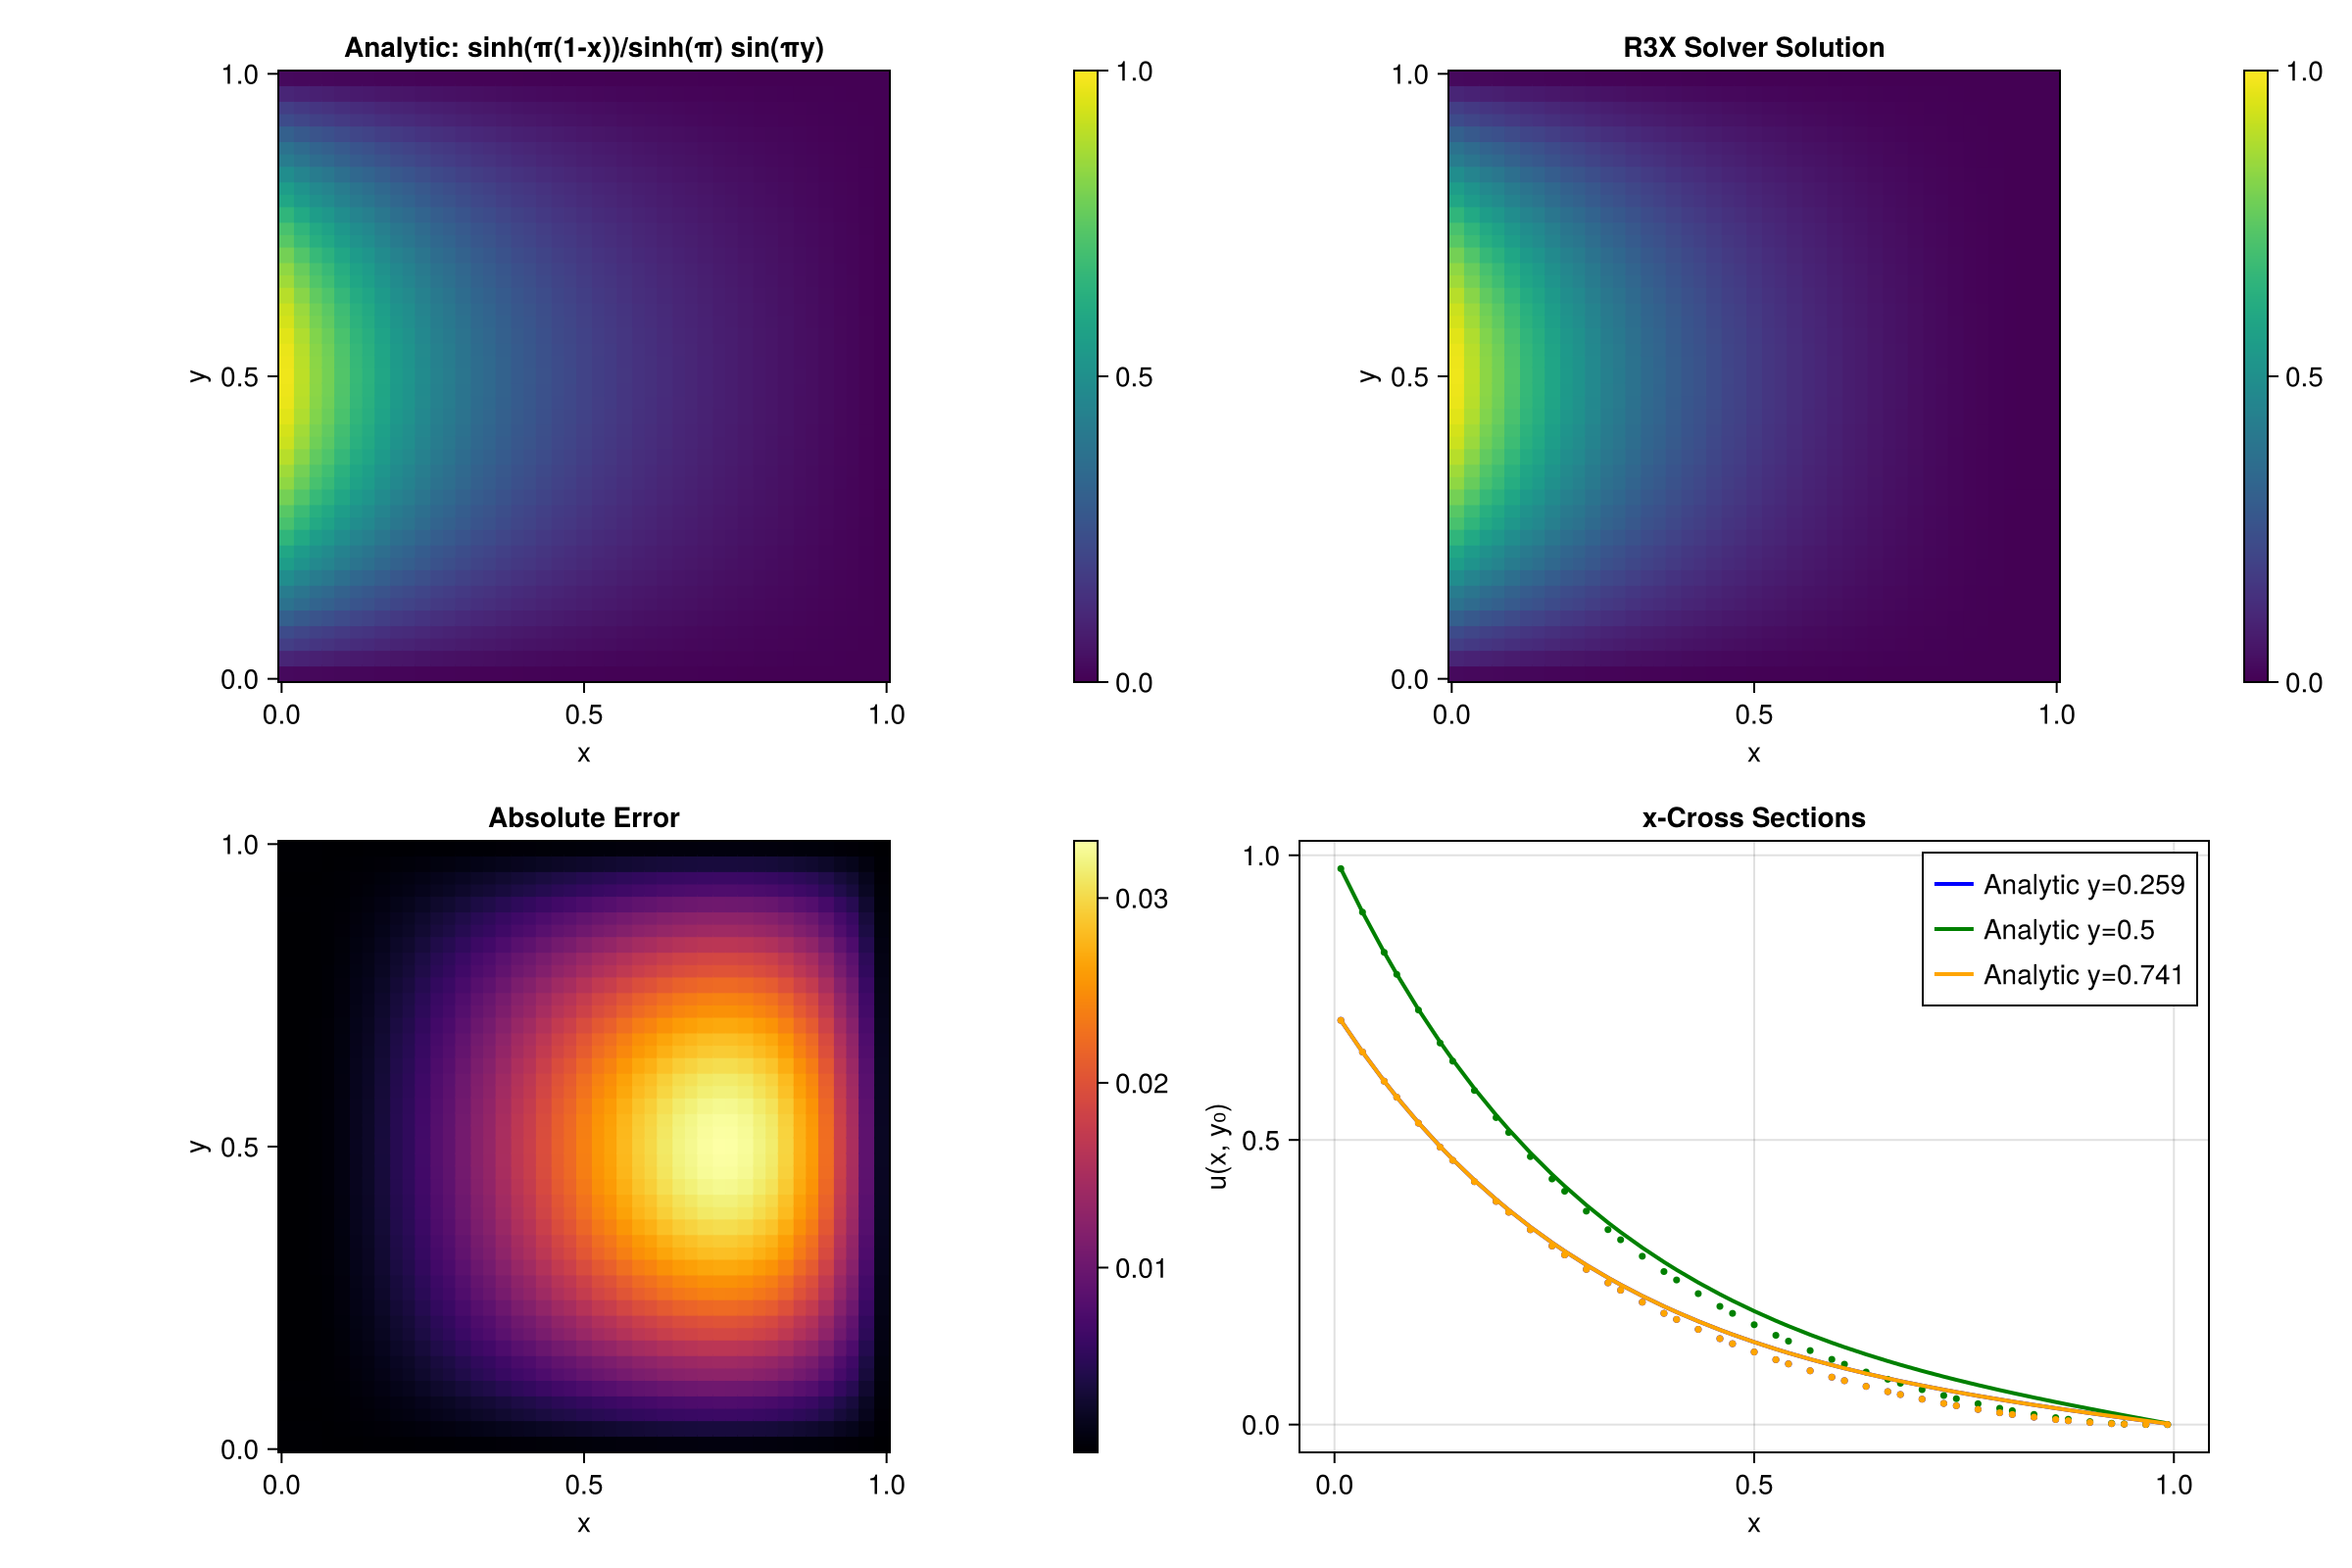

In [9]:
# ── Example 3: Visualization — 2D heatmaps ───────────────────────────────────
# Reshape flattened solution to 2D (i outer → rows, j inner → cols)
u_sol_2d  = reshape(sol3.physical, jDim, iDim3)'   # (iDim3, jDim)
u_true_2d = reshape(u3_true,       jDim, iDim3)'
err_2d    = abs.(u_sol_2d .- u_true_2d)

fig3 = Figure(size = (1200, 800))

clim = (0.0, 1.0)

ax3a = Axis(fig3[1,1], xlabel = "x", ylabel = "y",
            title = "Analytic: sinh(π(1-x))/sinh(π) sin(πy)", aspect = DataAspect())
hm3a = heatmap!(ax3a, x_pts, y_mish, u_true_2d; colormap = :viridis, colorrange = clim)
Colorbar(fig3[1,2], hm3a)

ax3b = Axis(fig3[1,3], xlabel = "x", ylabel = "y",
            title = "R3X Solver Solution", aspect = DataAspect())
hm3b = heatmap!(ax3b, x_pts, y_mish, u_sol_2d; colormap = :viridis, colorrange = clim)
Colorbar(fig3[1,4], hm3b)

ax3c = Axis(fig3[2,1], xlabel = "x", ylabel = "y",
            title = "Absolute Error", aspect = DataAspect())
hm3c = heatmap!(ax3c, x_pts, y_mish, err_2d; colormap = :inferno)
Colorbar(fig3[2,2], hm3c)

# Cross-sections at selected y values
ax3d = Axis(fig3[2,3], xlabel = "x", ylabel = "u(x, y₀)",
            title = "x-Cross Sections")
for (frac, col) in [(0.25, :blue), (0.5, :green), (0.75, :orange)]
    iy = argmin(abs.(y_mish .- frac))
    y_val = round(y_mish[iy], digits=3)
    lines!(ax3d, x_pts, u_true_2d[:, iy], color = col, linewidth = 2,
           label = "Analytic y=$y_val")
    scatter!(ax3d, x_pts, u_sol_2d[:, iy], color = col, markersize = 5)
end
axislegend(ax3d, position = :rt)

fig3

---
## Example 3b — Verifying All Three BC Components on the 2D Boundary

To confirm R3X properly constrains $u$, $u'$, and $u''$ on the 2D left boundary,
we evaluate the solver solution and its x-derivatives at $x = 0$ and compare
against the prescribed boundary data.

BC component errors at x=0:
  |u  - u_exact|  max = 0.00013114257096370763
  |u' - u'_exact| max = 0.00041353817631356593
  |u''- u''_exact|max = 0.0012943252955548434


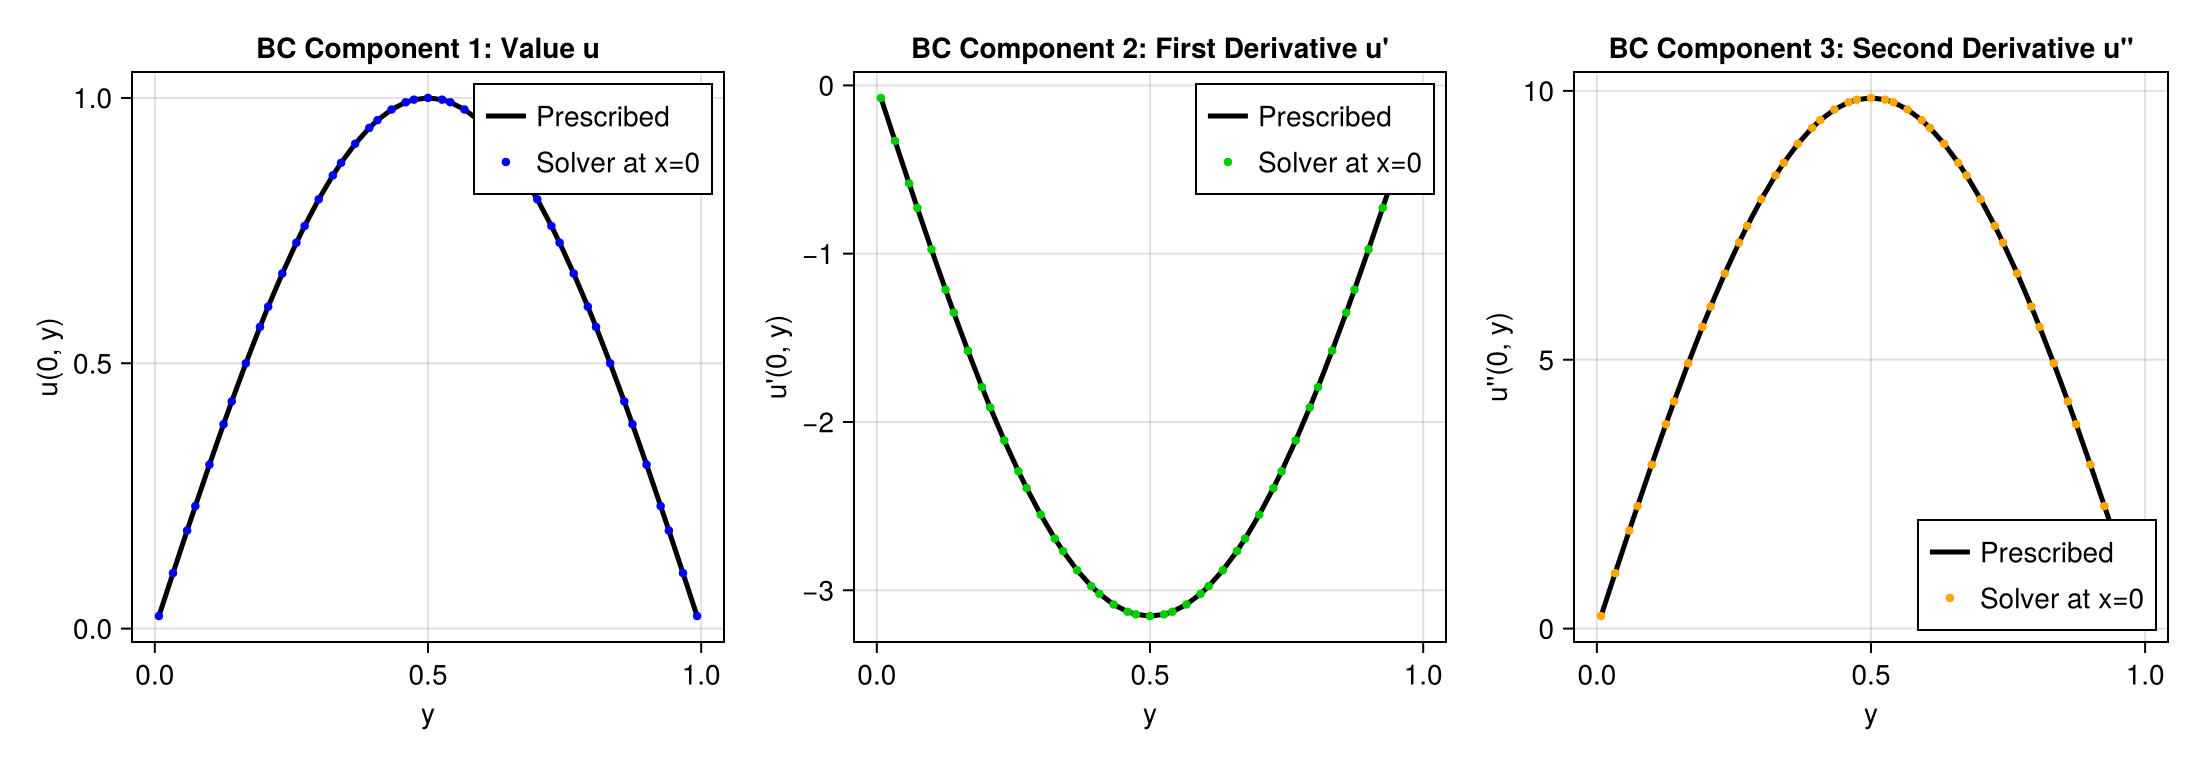

In [10]:
# ── Example 3b: Check all 3 BC components at the left boundary ───────────────
# Evaluate the solver solution at x=0 exactly using per-mode i-spline SItransform,
# then reconstruct physical y-values from the j-spectral modes.

b_iDim3 = grid3.params.b_iDim
x_bnd = grid3.params.iMin   # x = 0

# Extract per-j-mode spectral coefficients from the full solution vector
# Full spectral ordering: (i outer, j inner), length = b_iDim * b_jDim
# a[(i-1)*b_jDim + j] = coeff for i-th i-basis, j-th j-basis
a_full = sol3.coefficients
a_by_jmode = [a_full[(i-1)*b_jDim + j] for j in 1:b_jDim, i in 1:b_iDim3]
# a_by_jmode[j, i] = coefficient; each row j is the i-coefficients for j-mode j

# For each j-mode, evaluate u(x=0), u'(x=0), u''(x=0) via 1D SItransform
sp_i = grid3.ibasis.data[1, 1].params
u_at_bnd_jmodes   = zeros(b_jDim)
udx_at_bnd_jmodes = zeros(b_jDim)
udxx_at_bnd_jmodes = zeros(b_jDim)

for j in 1:b_jDim
    a_j = a_by_jmode[j, :]
    u_at_bnd_jmodes[j]    = CubicBSpline.SItransform(sp_i, a_j, x_bnd, 0)
    udx_at_bnd_jmodes[j]  = CubicBSpline.SItransform(sp_i, a_j, x_bnd, 1)
    udxx_at_bnd_jmodes[j] = CubicBSpline.SItransform(sp_i, a_j, x_bnd, 2)
end

# Reconstruct physical y-values from j-spectral using the j-basis SItransform
# The j-basis splines evaluate at the j-mish points
sp_j = grid3.jbasis.data[1, 1].params
u_left_solver    = CubicBSpline.SItransform(sp_j, u_at_bnd_jmodes)
udx_left_solver  = CubicBSpline.SItransform(sp_j, udx_at_bnd_jmodes)
udxx_left_solver = CubicBSpline.SItransform(sp_j, udxx_at_bnd_jmodes)

# Analytic values at left boundary
u_left_exact    = [u3_exact(0.0, y)     for y in y_mish]
udx_left_exact  = [u3_exact_dx(0.0, y)  for y in y_mish]
udxx_left_exact = [u3_exact_dxx(0.0, y) for y in y_mish]

println("BC component errors at x=0:")
println("  |u  - u_exact|  max = ", maximum(abs.(u_left_solver .- u_left_exact)))
println("  |u' - u'_exact| max = ", maximum(abs.(udx_left_solver .- udx_left_exact)))
println("  |u''- u''_exact|max = ", maximum(abs.(udxx_left_solver .- udxx_left_exact)))

fig3b = Figure(size = (1100, 380))

ax3b1 = Axis(fig3b[1,1], xlabel = "y", ylabel = "u(0, y)",
             title = "BC Component 1: Value u")
lines!(ax3b1, y_mish, u_left_exact, label = "Prescribed", linewidth = 2.5, color = :black)
scatter!(ax3b1, y_mish, u_left_solver, label = "Solver at x=0", markersize = 6, color = :blue)
axislegend(ax3b1, position = :rt)

ax3b2 = Axis(fig3b[1,2], xlabel = "y", ylabel = "u'(0, y)",
             title = "BC Component 2: First Derivative u'")
lines!(ax3b2, y_mish, udx_left_exact, label = "Prescribed", linewidth = 2.5, color = :black)
scatter!(ax3b2, y_mish, udx_left_solver, label = "Solver at x=0", markersize = 6, color = :green3)
axislegend(ax3b2, position = :rt)

ax3b3 = Axis(fig3b[1,3], xlabel = "y", ylabel = "u''(0, y)",
             title = "BC Component 3: Second Derivative u''")
lines!(ax3b3, y_mish, udxx_left_exact, label = "Prescribed", linewidth = 2.5, color = :black)
scatter!(ax3b3, y_mish, udxx_left_solver, label = "Solver at x=0", markersize = 6, color = :orange)
axislegend(ax3b3, position = :rb)

fig3b

---
## Summary

| Example | Grid | R3X Boundary | All 3 Components? | Solver? |
|:--------|:-----|:-------------|:-------------------|:--------|
| 1 | `R` (1D) | Both sides, analytic function | $u$, $u'$, $u''$ all non-zero | Transform round-trip |
| 2 | `R` (1D) | Both sides, $u(0)=1$, $u(1)=3$ | Yes (via manufactured solution) | Poisson $u'' = f$ |
| 3 | `RR` (2D) | Left: $\sin(\pi y)$, Right: 0 | Yes (spatially varying) | Laplace $\nabla^2 u = 0$ |

### Key takeaways
- **R3X is a drop-in replacement for R3** — same gammaBC matrix, but the `SAtransform!` automatically accounts for the inhomogeneous background `ahat`
- **`set_boundary_values!`** handles the spectral-space transform of boundary data internally for 2D grids
- **All three BC components** ($u$, $u'$, $u''$) are enforced simultaneously, giving the solver full rank-3 control at the boundary
- **Grid nesting workflow**: at each timestep, evaluate the outer grid at the inner boundary, call `set_boundary_values!`, then `solve()`